In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

In [ ]:
class Layer:
    def __init__(self, nin, nout):
        self.W = np.random.randn(nin, nout)
        self.b = np.zeros((1, nout))

        self.Vdw = np.zeros_like(self.W)
        self.Vdb = np.zeros_like(self.b)

    def activation(self, X, act_name="sigmoid"):
        match act_name:
            case "sigmoid":
                return 1 / (1 + np.exp(-X))
            case "relu":
                return np.max(X, 0)
            case "tanh":
                return np.tanh(X)

    def activation_deriv(self, X, act_name="sigmoid"):
        match act_name:
            case "sigmoid":
                return self.activation(X) * (1 - self.activation(X))
            case "relu":
                return (X > 0).astype(int)
            case "tanh":
                return 1 - np.tanh(X) ** 2

    def forward(self, X, act_name="sigmoid"):
        self.X = X
        self.Z = np.dot(X, self.W) + self.b
        self.A = self.activation(self.Z, act_name)

        return self.A

    def update_params(self, lr=0.01):
        self.W -= lr * self.dW
        self.b -= lr * self.db

    def update_params_with_momentum(self, lr=0.01, beta=0.9):
        self.Vdw = beta * self.Vdw + (1 - beta) * self.dW
        self.Vdb = beta * self.Vdb + (1 - beta) * self.db

        self.W -= lr * self.dW
        self.b -= lr * self.db


class MLP:
    def __init__(self, layer_dims):
        self.layers = []
        for i in range(len(layer_dims) - 1):
            self.layers.append(Layer(layer_dims[i], layer_dims[i + 1]))

    def forward(self, X):
        for layer in self.layers:
            X = layer.forward(X)
        return X

    def backward(self, Y):
        m = Y.shape[0]
        last_layer = self.layers[-1]
        dZ = last_layer.A - Y

        for i in reversed(range(len(self.layers) )):
            layer = self.layers[i]
            layer.dW = (1 / m) * np.dot(layer.X.T, dZ)
            layer.db = (1 / m) * np.sum(dZ, axis=0, keepdims=True)

            if i > 0:
                prev_layer = self.layers[i - 1]
                dZ = np.dot(dZ, layer.W.T) * prev_layer.activation_deriv(prev_layer.Z)

    def update(self, lr, beta):
        for layer in self.layers:
            layer.update_params_with_momentum(lr, beta)

    def train(self, X, Y, lr=0.1, beta=0.9, epochs=10000):
        for epoch in range(epochs):
            self.forward(X)
            self.backward(Y)
            self.update(lr, beta)

            if epoch % 1000 == 0:
                predictions = (self.layers[-1].A >= 0.5).astype(int)
                acc = np.sum(predictions == Y) / Y.size
                print(f"Epoch: {epoch} | Accuracy: {acc:.4f}")


In [55]:
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
Y = np.array([[0], [1], [1], [0]])

# Build a network with 2 inputs -> 4 hidden neurons -> 1 output neuron
model = MLP([2, 4, 1])
model.train(X, Y, lr=0.5, beta=0.9, epochs=5000)

print("\nFinal Predictions:")
print(np.round(model.forward(X), 4))

Epoch: 0 | Accuracy: 0.2500
Epoch: 1000 | Accuracy: 1.0000
Epoch: 2000 | Accuracy: 1.0000
Epoch: 3000 | Accuracy: 1.0000
Epoch: 4000 | Accuracy: 1.0000

Final Predictions:
[[0.0011]
 [0.9962]
 [0.9963]
 [0.0081]]


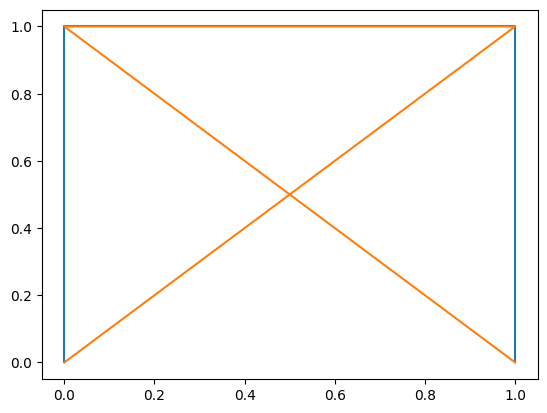

In [ ]:
plt.plot(X, Y)